In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))


import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import torchvision.transforms.functional as TF
import pandas as pd
import matplotlib.pyplot as plt


from src.dataset.bbbc038 import BBBC038Dataset, SegmentationTransform
from src.nn.models import UNet, train_loop, test_loop
from src.nn.optimizers import create_optimizer
from src.plot.plot import plot_resultados
from src.nn.metrics import *

In [ ]:
# Definindo a seed e o device (GPU se disponível, caso contrário CPU)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Definindo o dataset, dataloaders, modelo, função de perda e otimizador
transform = SegmentationTransform(
    size=(128, 128)
)
dataset = BBBC038Dataset(
    root="../data/stage1_train",
    transform=transform
)
train_len = int(0.8 * len(dataset))
val_len = len(dataset) - train_len
train_dataset, val_dataset = random_split(
    dataset,
    [train_len, val_len],
    generator=torch.Generator().manual_seed(SEED)
)

batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)
eval_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

model = UNet(num_classes=2).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = create_optimizer("Adam",model,lr=1e-3)

Epoch 1/5 | Train Loss: 0.4103 | Val Loss: 0.5745 | Pixel Accuracy: 0.8667


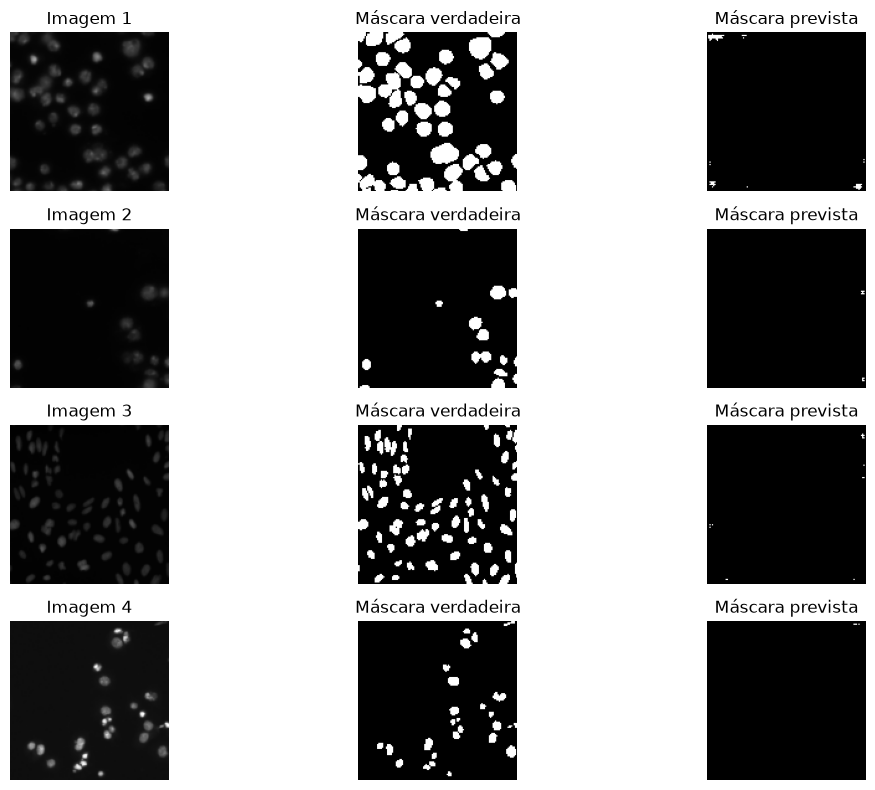

Epoch 2/5 | Train Loss: 0.2847 | Val Loss: 0.3721 | Pixel Accuracy: 0.9280


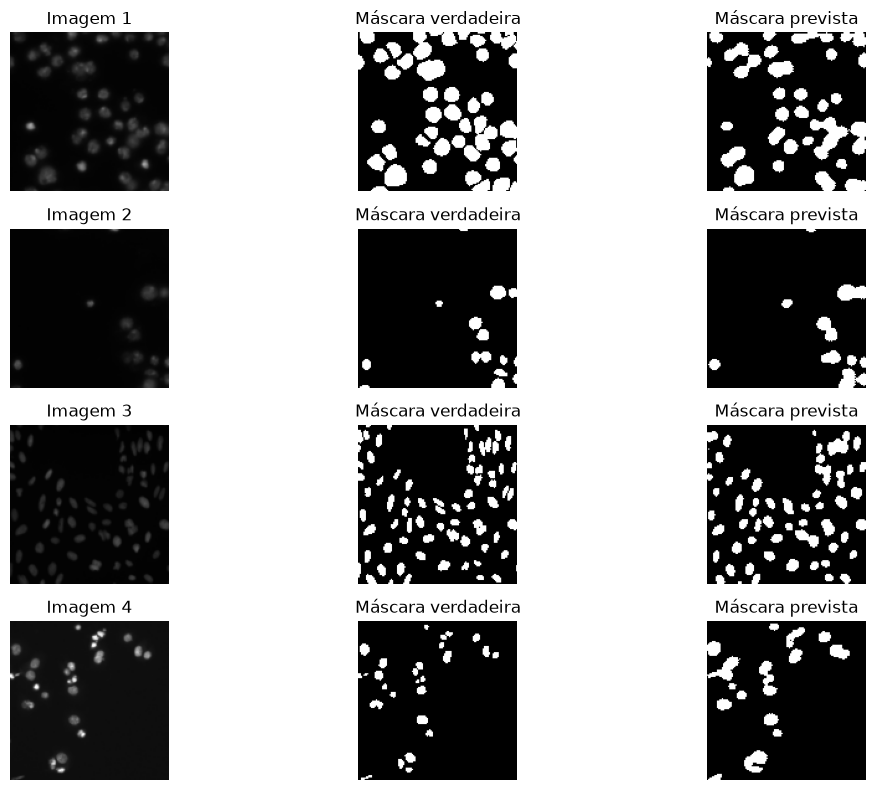

Epoch 3/5 | Train Loss: 0.2313 | Val Loss: 0.2787 | Pixel Accuracy: 0.9437


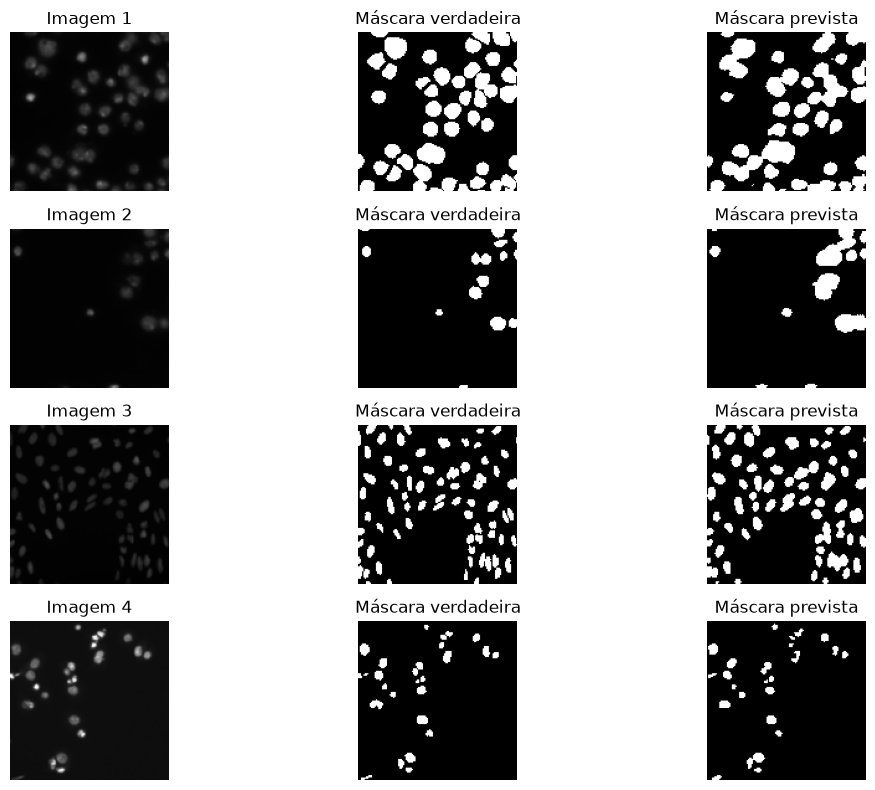

Epoch 4/5 | Train Loss: 0.1964 | Val Loss: 0.2158 | Pixel Accuracy: 0.9612


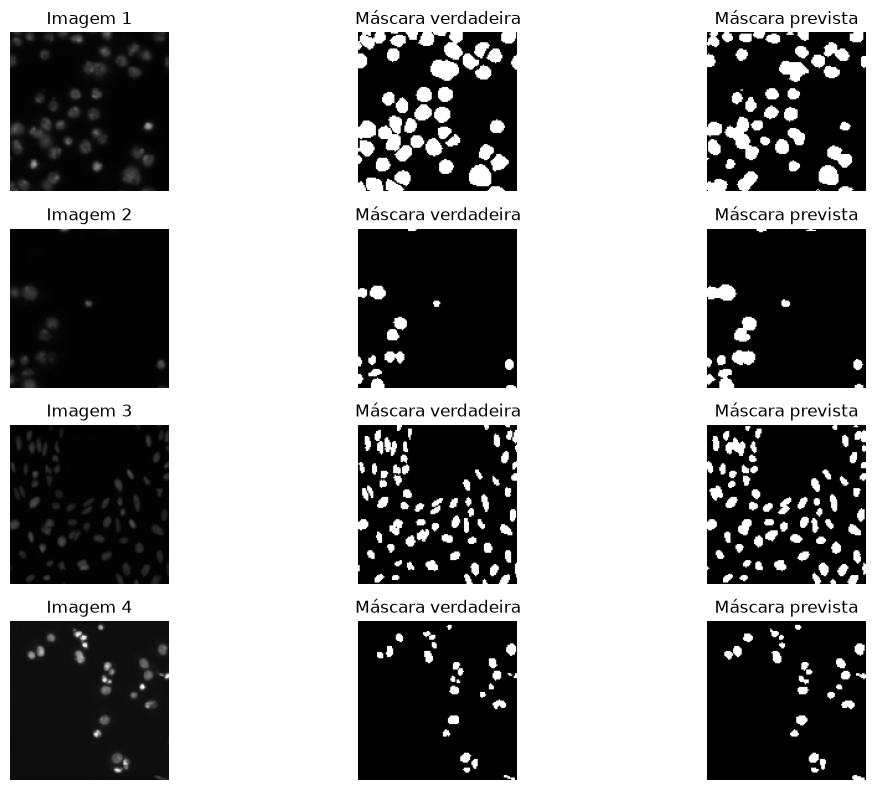

Epoch 5/5 | Train Loss: 0.1685 | Val Loss: 0.1569 | Pixel Accuracy: 0.9664


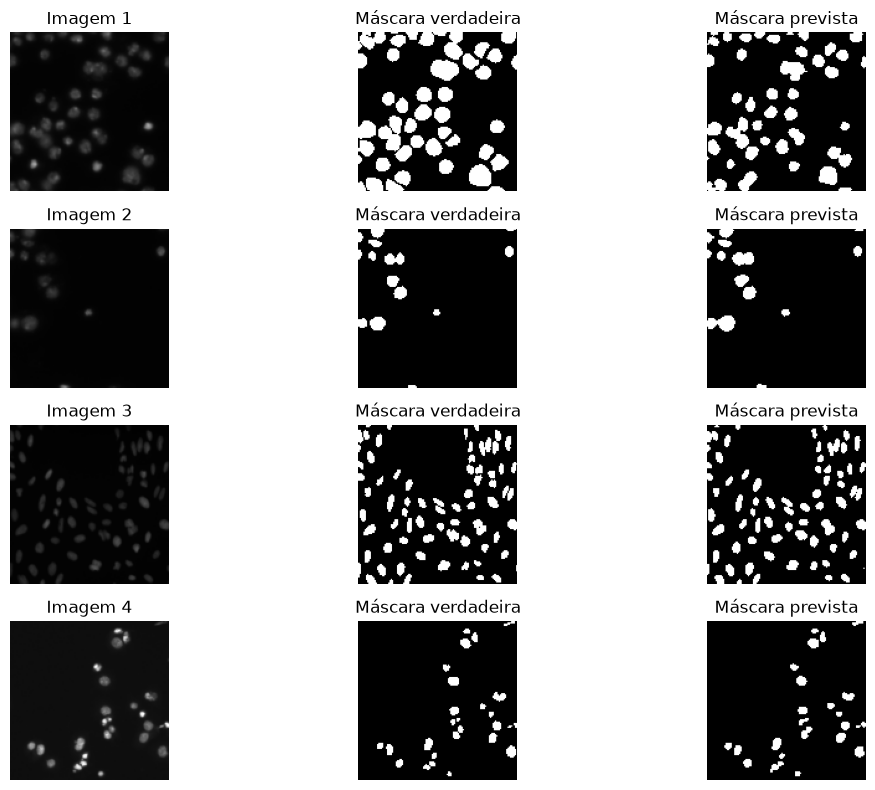

In [3]:
# Treinamento e validação do modelo
NUM_EPOCHS = 5
for epoch in range(NUM_EPOCHS):
    train_loss = train_loop(train_loader, device, model, loss_fn, optimizer)
    val_loss, pixel_acc = test_loop(val_loader, device, model, loss_fn)
    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Pixel Accuracy: {pixel_acc:.4f}"
    )
    plot_resultados(model, val_loader, device, num_images=4)

In [ ]:
def instance_scores(foreground_probability, instances):
    """
    Calcula uma confiança para cada instância.

    A confiança é a probabilidade média de foreground
    dentro da região da instância.
    """

    scores = []

    for instance in instances:
        if instance.sum() == 0:
            scores.append(0.0)
            continue

        score = foreground_probability[instance].mean()
        scores.append(float(score))

    return scores

In [ ]:
def evaluate_image(pred_instances, target_instances, pred_scores, iou_threshold):
    """
    Avalia uma imagem.

    Retorna:
        lista de 1/0 indicando TP ou FP para
        cada previsão, ordenada por score.
    """

    if len(pred_instances) == 0:
        return [], len(target_instances)

    # Ordenar pelas maiores confianças
    order = np.argsort(-np.asarray(pred_scores))

    pred_instances = [pred_instances[i] for i in order]

    pred_scores = [pred_scores[i] for i in order]

    matched_targets = set()

    tp_flags = []

    for pred in pred_instances:

        best_iou = 0.0
        best_target = None

        for target_idx, target in enumerate(target_instances):

            if target_idx in matched_targets:
                continue

            iou = instance_IoU(pred, target)

            if iou > best_iou:
                best_iou = iou
                best_target = target_idx

        if (best_target is not None and best_iou >= iou_threshold):

            matched_targets.add(best_target)

            # True Positive
            tp_flags.append(1)

        else:

            # False Positive
            tp_flags.append(0)

    false_negatives = (len(target_instances) - len(matched_targets))

    return tp_flags, false_negatives

In [ ]:
def evaluate_instances(model, dataloader, dataset, device, threshold=0.5):
    """
    Executa avaliação por instâncias.

    Retorna:
        predictions
        ground_truths
        scores
        count_errors
    """

    model.eval()

    predictions = []
    ground_truths = []
    scores = []
    count_errors = []

    with torch.no_grad():

        for batch_indices, (X, y) in enumerate(dataloader):

            X = X.to(device)

            outputs = model(X)

            probs = torch.softmax(outputs, dim=1)

            foreground = probs[:, 1]

            binary_masks = (foreground > threshold).cpu().numpy()

            for batch_i in range(X.shape[0]):

                pred_mask = binary_masks[batch_i]

                pred_instances = connected_components(pred_mask)

                probability = (
                    foreground[
                        batch_i
                    ]
                    .cpu()
                    .numpy()
                )

                pred_scores = instance_scores(probability, pred_instances)

                dataset_index = (
                    dataloader
                    .dataset
                    .indices[
                        batch_indices *
                        dataloader.batch_size
                        + batch_i
                    ]
                )

                sample = dataset.samples[
                    dataset_index
                ]

                image = Image.open(
                    sample["image"]
                ).convert("RGB")

                gt_instances = (
                    dataset._load_instance_masks(
                        sample["masks"],
                        image.size
                    )
                )

                # Atenção:
                # as máscaras precisam estar na mesma
                # resolução da saída do modelo.

                resized_gt = []

                for gt in gt_instances:

                    gt_image = Image.fromarray(
                        gt.astype(np.uint8) * 255
                    )

                    gt_image = TF.resize(
                        gt_image,
                        pred_mask.shape,
                        interpolation=TF.InterpolationMode.NEAREST
                    )

                    resized_gt.append(
                        np.array(gt_image) > 0
                    )

                # --------------------------------------------
                # Salvar
                # --------------------------------------------

                predictions.append(pred_instances)
                ground_truths.append(resized_gt)

                scores.append(pred_scores)

                count_errors.append(
                    {
                        "true": len(resized_gt),
                        "pred": len(pred_instances),
                        "error": abs(
                            len(pred_instances)
                            - len(resized_gt)
                        )
                    }
                )

    return (
        predictions,
        ground_truths,
        scores,
        count_errors
    )

In [ ]:
predictions, ground_truths, scores, count_errors = evaluate_instances(
    model,
    val_loader,
    dataset,
    device,
    threshold=0.5
)

map_value, aps = mean_average_precision(
    predictions,
    ground_truths,
    scores
)

print("\nAP por IoU:")

for threshold, ap in aps.items():
    print(
        f"AP@{threshold:.2f}: {ap:.4f}"
    )

print(
    f"\nmAP@50:95 = {map_value:.4f}"
)

In [ ]:
for threshold in np.arange(
    0.50,
    0.951,
    0.05
):

    tp, fp, fn = count_tp_fp_fn(
        predictions,
        ground_truths,
        threshold
    )

    print(
        f"IoU={threshold:.2f} | "
        f"TP={tp} | "
        f"FP={fp} | "
        f"FN={fn}"
    )

In [ ]:
df = pd.DataFrame(
    count_errors
)

print(df)

In [ ]:
mean_count_error = df["error"].mean()

print(
    f"Erro médio de contagem: "
    f"{mean_count_error:.4f}"
)

df["density"] = df["true"] / (
    256 * 256
)

In [ ]:
grouped = (
    df
    .groupby("density")["error"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.plot(
    grouped.index,
    grouped.values,
    marker="o"
)

plt.xlabel(
    "Número de objetos verdadeiros"
)

plt.ylabel(
    "Erro absoluto médio de contagem"
)

plt.title(
    "Erro de contagem em função da densidade de objetos"
)

plt.grid()

plt.tight_layout()

plt.show()